# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [2]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

#Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [3]:
df.shape
df.info()
df.head()

<class 'pandas.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       10886 non-null  int64  
 1   holiday      10886 non-null  int64  
 2   workingday   10886 non-null  int64  
 3   weather      10886 non-null  int64  
 4   temp         10886 non-null  float64
 5   atemp        10886 non-null  float64
 6   humidity     10886 non-null  int64  
 7   windspeed    10886 non-null  float64
 8   casual       10886 non-null  int64  
 9   registered   10886 non-null  int64  
 10  count        10886 non-null  int64  
 11  date         10886 non-null  object 
 12  day          10886 non-null  int32  
 13  week         10886 non-null  UInt32 
 14  weekday_num  10886 non-null  int32  
 15  weekday      10886 non-null  str    
 16  year         10886 non-null  int32  
 17  month        10886 non-null  int32  
 18  hour         10886 non

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [4]:
df.columns
df.nunique()

season           4
holiday          2
workingday       2
weather          4
temp            49
atemp           60
humidity        89
windspeed       28
casual         309
registered     731
count          822
date           456
day             19
week            46
weekday_num      7
weekday          7
year             2
month           12
hour            24
dtype: int64

In [5]:
df['date'].min(), df['date'].max()

(datetime.date(2011, 1, 1), datetime.date(2012, 12, 19))

Набір даних містить 10886 рядків та 19 колонок.
Дані охоплюють період з 01.01.2011 по 19.12.2012.
Один рядок відповідає даним за одну годину конкретного дня.
Таким чином, рівень деталізації — погодинний.
Дані дозволяють аналізувати сезонність, погодні фактори, вплив свят та робочих днів на кількість орендованих велосипедів.

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


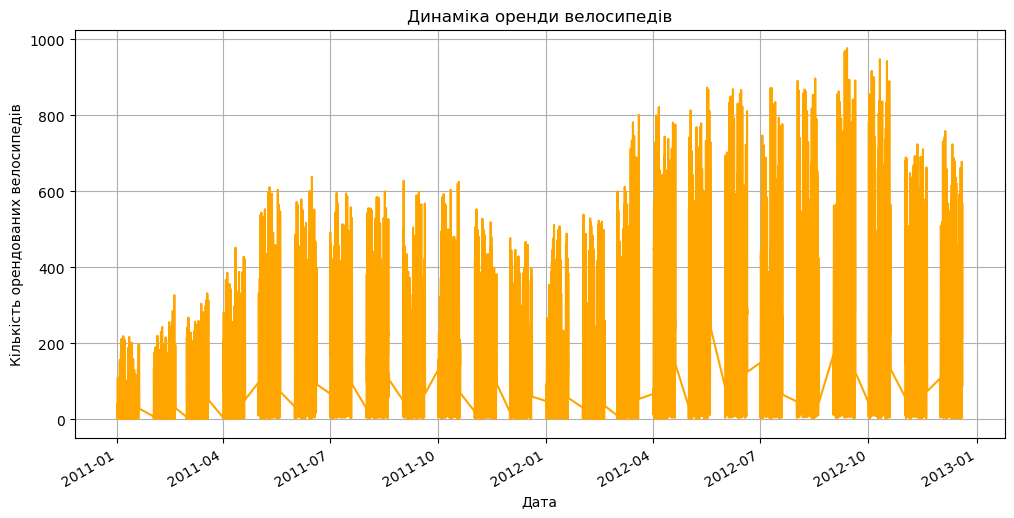

In [40]:
df['count'].plot(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='Дата',
    ylabel='Кількість орендованих велосипедів',
    color = 'orange',
    grid=True);

На графіку видно чітку річну сезонність із піком у літні місяці та спадом узимку.
Також спостерігається загальний тренд зростання з 2011 до 2012 року.
«Заломи» спричинені сезонністю, погодними факторами та використанням місячної агрегації.
Для згладжування можна застосувати середнє значення за міцяць.



## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [28]:
import matplotlib.pyplot as plt

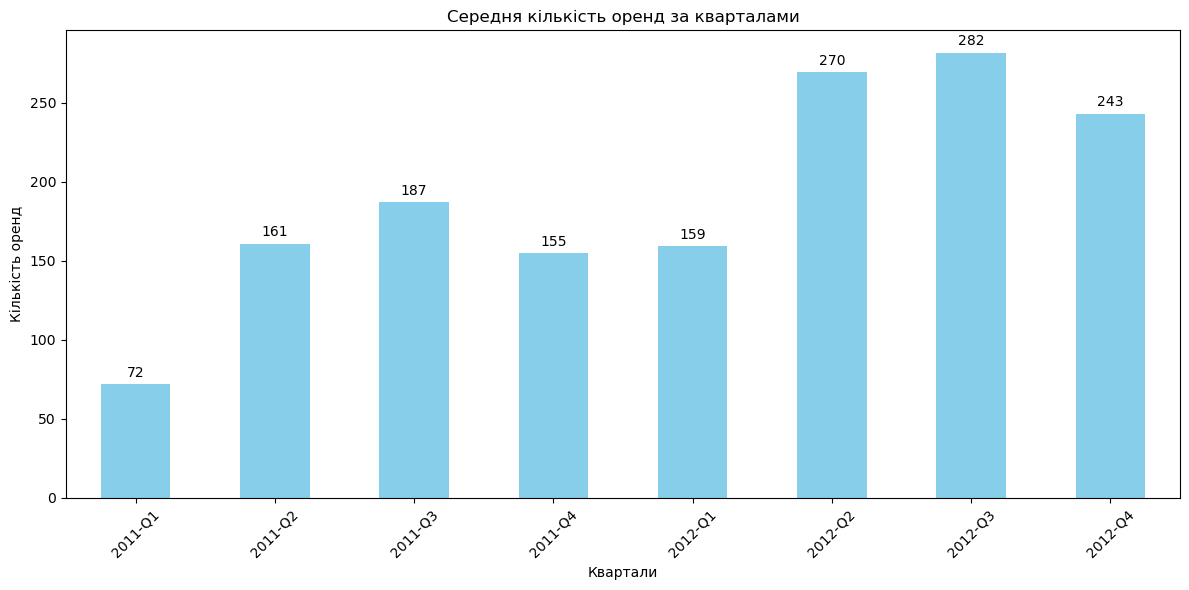

In [36]:
df_q = df['count'].resample('QE').mean()
ax = df_q.plot.bar(
    figsize=(12,6),
    color='skyblue',
    title='Середня кількість оренд за кварталами',
    ylabel='Кількість оренд',
    xlabel='Квартали'
)

ax.set_xticklabels(
    [f"{d.year}-Q{d.quarter}" for d in df_q.index],
    rotation=45
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()


In [37]:
max_value = df_q.max()
min_value = df_q.min()

ratio = max_value / min_value
ratio

np.float64(3.918132973423351)

В 3 кварталі 2011 та 2012 найбільша середня кількість оренди велосипедів, це пов'язано з літнім сезоном (температура повітря зростає, опади незначні, більша довжина світлового дня).
Рівень оренди відрізняється приблизно у 4 раза.
Це свідчить про сильну сезонність попиту.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


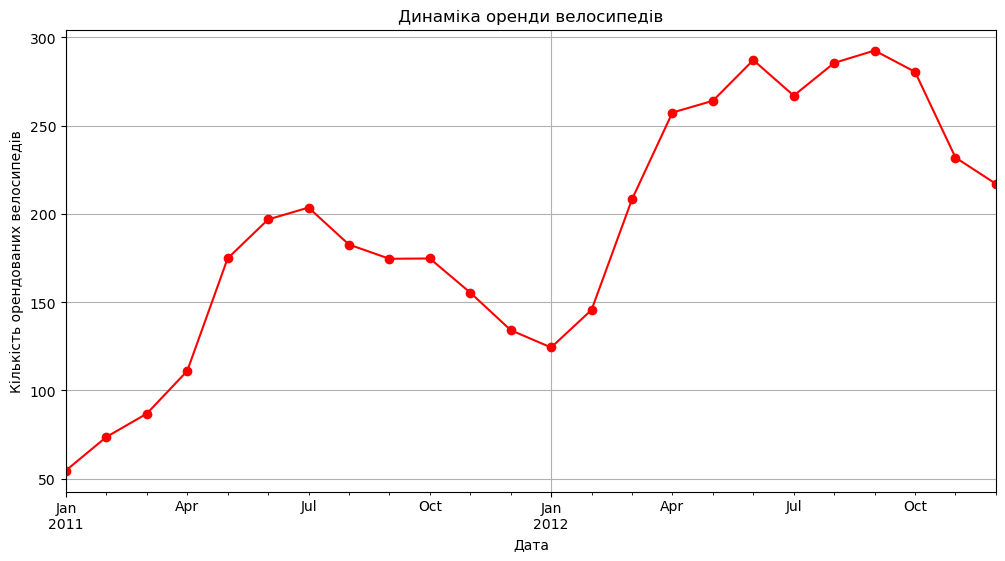

In [44]:
df['count'].resample('ME').mean().plot(
    marker='o',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='Дата',
    ylabel='Кількість орендованих велосипедів',
    color = 'red',
    grid=True);

Пік оренди припадає на літні місяці (червень–серпень), а мінімальні значення спостерігаються у зимовий період (січень–лютий).
Ця закономірність повністю узгоджується з результатами квартального аналізу, де Q3 демонструє найвищі показники, а Q1 — найнижчі.
Основним фактором сезонності є кліматичні умови: підвищення температури стимулює попит, тоді як холодна та дощова погода суттєво його знижує.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

In [80]:
weather = df['weather'].value_counts().sort_index()
weather

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

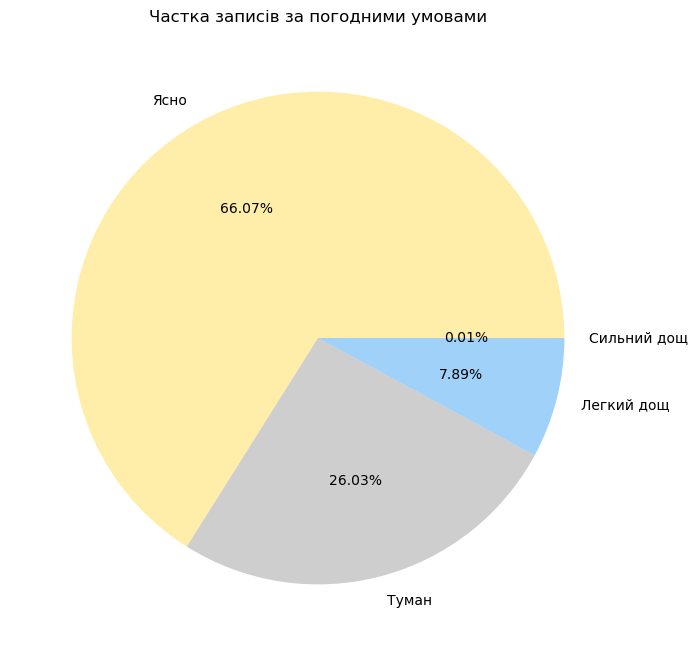

In [102]:
 weather.plot.pie(
    figsize=(10, 8),
    autopct='%1.2f%%',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title='Частка записів за погодними умовами',
    ylabel='',
    colors=['#FFDE54','#9E9E9E', '#42A5F5', '#EF5350'],
    wedgeprops={'alpha': 0.5}
 );

У датасеті переважає ясна погода, що становить понад половину всіх записів.
Дні з сильним дощем зустрічаються рідко (менше 1%).
Спостерігається чітка залежність попиту від погодних умов: зі зростанням індексу погоди (погіршенням умов) середня кількість оренд зменшується.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

''

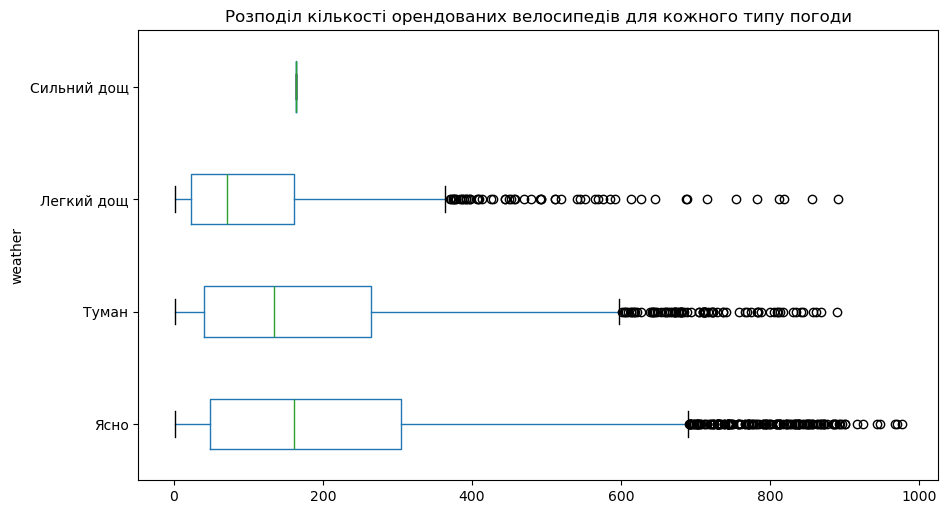

In [116]:
ax = df.boxplot(column='count',
    by='weather',
    figsize=(10, 6),
    grid = False,
    vert=False,
    ylabel = '',
           )
ax.set_yticklabels(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.title('Розподіл кількості орендованих велосипедів для кожного типу погоди')
plt.suptitle('')
;

Найбільший розкид кількості оренд спостерігається при ясній погоді.
є викиди при ясній погоді, при тумані, при легкому дощі.
Найвище медіанне значення оренд зафіксовано при ясній погоді, що підтверджує суттєвий вплив погодних умов на попит.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

''

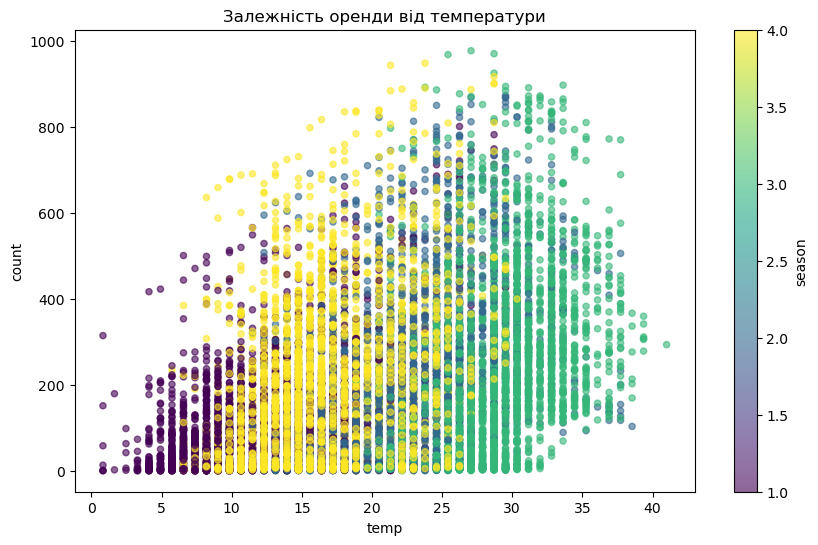

In [126]:
df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='viridis',
    title='Залежність оренди від температури',
    figsize = (10, 6),
    alpha= 0.6)
;

Між температурою та кількістю оренд спостерігається помірний позитивний зв’язок. Зі зростанням температури попит на оренду велосипедів збільшується. Це підтверджується як візуальним аналізом scatter plot, так і коефіцієнтом кореляції.

In [124]:
df[['temp', 'count']].corr()

,temp,count
temp,1.000000,0.394454
count,0.394454,1.000000


## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [127]:
df_week = (
    df.groupby('weekday')[['casual', 'registered']]
      .mean()
)

In [128]:
df_week

,casual,registered
weekday,,
Friday,31.001962,166.842381
Monday,29.843972,160.546744
Saturday,63.625000,133.040404
Sunday,57.051298,123.788474
Thursday,24.007083,173.289118
Tuesday,22.979207,166.744639
Wednesday,22.521599,165.889749


''

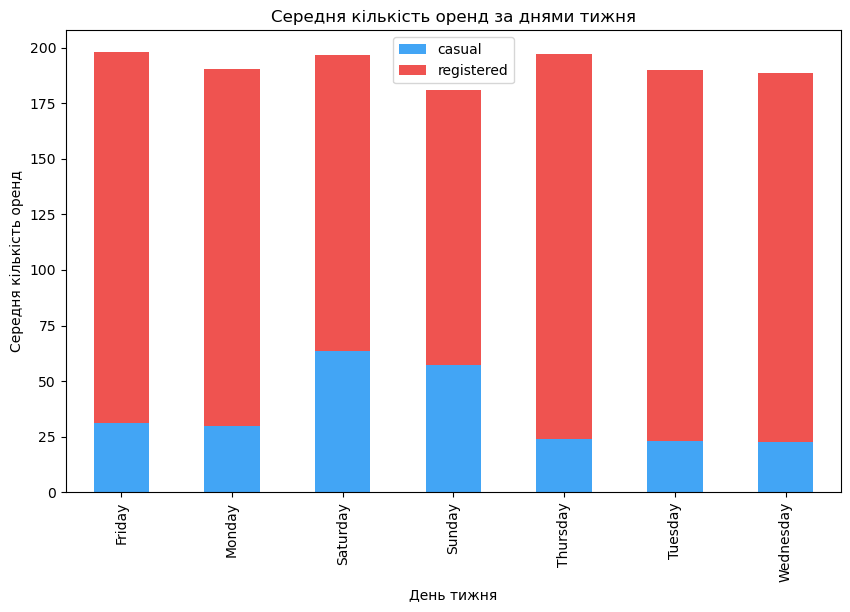

In [136]:
ax = df_week.plot.bar(
    stacked=True,
    figsize=(10,6),
    color=['#42A5F5', '#EF5350'],
    title = 'Середня кількість оренд за днями тижня',
    ylabel = 'Середня кількість оренд',
    xlabel = 'День тижня'
)

;


Зареєстровані користувачі здійснюють більшу кількість оренд у будні дні, що свідчить про використання сервісу як щоденного транспорту.
Натомість частка випадкових користувачів зростає у вихідні, що пов’язано з рекреаційним використанням велосипедів.